<a href="https://colab.research.google.com/github/mpellegrino-hub/SchoolProjects/blob/main/Part2_Perceptron_with_GD_Skeleton_v2_dataset_fix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h4> Any sort of collaboration and external help should be explicitly mentioned in your submission.</h4>

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

<h2>Homework 1</h2>

<p>In this assignment, you will implement a numerical approach to gradient descent and use it to develop the perceptron algorithm. This process will be broken down into several stages, as described below. First, we'll explore how to perform gradient descent numerically.</p>

<h3>The Method of Finite Differences</h3>

<p>Given a function <i>f(x)</i>, the analytical approach to gradient descent—i.e., finding the value of <i>x</i> that minimizes <i>f(x)</i>—involves computing <i>f'(x)</i> and iterating as follows, where <i>α ∈ (0, 1]</i> is the learning rate:</p>

<pre>
x = 0
while not converged:
    x = x - α * f'(x)
</pre>

<p>If you cannot compute <i>f'(x)</i> analytically, you can estimate it using the finite difference method, which is expressed as follows for a sufficiently small <i>ε</i>:</p>

<pre>
f'(x) ≈ (f(x + ε) - f(x - ε)) / (2ε)
</pre>

<p>The finite difference method assumes that over very small intervals, the function behaves linearly. Therefore, the slope of the tangent line can be estimated as the difference between the function values at the ends of the interval divided by the interval width.</p>

<p>For example, the slope of <i>f(x) = x²</i> at <i>x = 1</i> can be estimated as:</p>

<p>
f'(1) = <sup>((1 + 0.001)² - (1 - 0.001)²)</sup> / <sub>(2 * 0.001)</sub>
</p>



In [2]:
e = 0.001
(math.pow(1 + e, 2) - math.pow(1 - e, 2))/(2*e)

1.9999999999998352

<p>Note that the number above is very close to what you would get analytically by taking derivatives:</p>

<pre>
f'(x) = 2x
so
f'(1) = 2 * 1 = 2
</pre>

<p>You'll use the method of finite differences to compute the derivative of a loss function with respect to the weights of a perceptron.</p>

<p>Below is a simple implementation of the method of finite differences for a univariate function. It is overly simple, running for a fixed number of iterations, and assuming constants for <i>ε</i> and <i>α</i>, but it works for simple cases.</p>


In [3]:
def fd_demo(f, x0):
    e = 0.001
    a = 0.01
    x = x0
    for _ in range(1000):
        g = (f(x + e) - f(x - e)) / (2*e)
        x = x - a * g
    return x

In [4]:
# x*x is minimized at 0
f = lambda x: x * x
fd_demo(f, 2)

3.365934714445534e-09

In [5]:
# sin(x) is minimized at lots of points, the closest to 2 is 3pi/2
f = lambda x: math.sin(x)
print(fd_demo(f, 2))
print(math.pi * 3 / 2)

4.711986618234112
4.71238898038469


<h3>Perceptron Class</h3>

<p>Below is a simple <code>Perceptron</code> class that you can use in this assignment. Feel free to use it as is, make changes, or write your own from scratch. This class initializes a weight vector with small random numbers and includes methods to compute the activation for an input and to produce a binary class label for an input.</p>

<p>Note that the class below does not maintain an explicit bias term <i>b</i>. You can add one or, better yet, ensure that all inputs, <i>x</i>, have a 1 in one of the positions.</p>


In [6]:
class Perceptron:

    def __init__(self, n):
        """
        n (int) - The length of x vectors that the classifier will process.
        """

        # Start with weights uniformly chosen from the range [-0.5, 0.5]
        self.weights = (np.random.rand(n) - 0.5).tolist()

    def activation(self, x):
        return np.dot(x, self.weights)

    def predict(self, x):
        return 1 if self.activation(x) > 0 else -1


<h3>Task 1: The Perceptron Loss</h3>

<p>Fill in the function below to compute the perceptron loss. Recall that the perceptron loss is 0 if the activation and the class label have the same sign; otherwise, it is <code>-y * activation</code>.</p>


In [7]:
def loss_perceptron(y, activation):
    if y * activation > 0:
      return 0
    else:
      return -y * activation

<h3>Task 2: One Step of Gradient Descent</h3>

<p>Complete <code>gd_step</code> so that it performs one weight update using the
given training example, loss function, learning rate, and the method of finite
differences.</p>

<p>Your function must:</p>

<ol>
    <li>Estimate the partial derivative of the loss with respect to each weight
        using central finite differences.</li>
    <li>Use the resulting gradient to compute
        <code>w_new = w - learning_rate * gradient</code>.</li>
    <li>Do not modify
        <code>clf.weights</code> in place. Describe what would be the issue if you update the original clf.weights and return that.</li>
    <li>Return the new weight vector </li>
</ol>

<p>This function will later be reused with a different loss function so that
you can observe how the choice of loss changes the learned classifier.</p>

In [8]:
def gd_step(clf, x, y, learning_rate, loss_fn, epsilon = 0.001):
    gradient = []

    #copy of the original weights
    original_weights = clf.weights.copy()

    for i in range(len(original_weights)):
        weights_plus = original_weights.copy()
        weights_minus = original_weights.copy()

        weights_plus[i] += epsilon
        weights_minus[i] -= epsilon

        activation_plus = np.dot(x, weights_plus)
        activation_minus = np.dot(x, weights_minus)

        loss_plus = loss_fn(y, activation_plus)
        loss_minus = loss_fn(y, activation_minus)

        derivative = (loss_plus - loss_minus) / (2 * epsilon)
        gradient.append(derivative)

    new_weights = []

    for weight, grad in zip(original_weights, gradient):
        new_weights.append(weight - learning_rate * grad)

    return new_weights

We should not change the original weights while calculating the gradient because each derivative should be based on the same starting set of weights. If we changed the weights as we calculated each derivative, later calculations would use already-modified values, which could make the gradient incorrect.


<h3>Training Data for the Tasks</h3>

<p>The code below generates a simple 2D dataset of <code>n</code> positive examples followed by <code>n</code> negative examples. The cell after that plots them. The code also prepends a 1 in each example so that the bias term will simply correspond to the first weight.</p>

In [9]:
rng = np.random.default_rng(42)
n = 10

X = np.concatenate((
    rng.random((n, 2)) + 1,
    rng.random((n, 2))
))

X = np.hstack((np.ones((2 * n, 1)), X))
Y = np.array([1] * n + [-1] * n)
colors = np.array(['r'] * n + ['g'] * n)

permutation = rng.permutation(2 * n)
X = X[permutation]
Y = Y[permutation]
colors = colors[permutation]

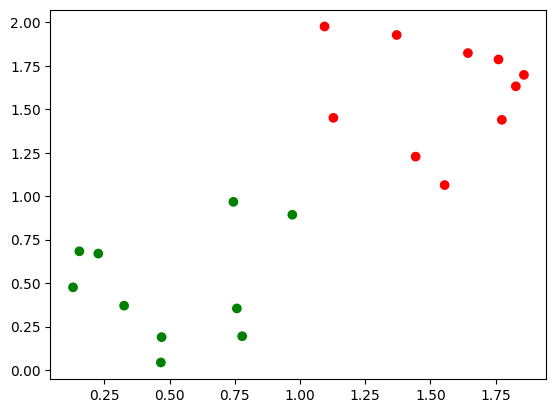

In [10]:
plt.scatter(X[:,1], X[:,2], c = colors)

<h3>Task 3: Train the Perceptron</h3>

<p>The code below applies <code>gd_step</code> to each training example.</p>

<p>Modify the training code so that:</p>

<ul>
    <li>training continues until one complete epoch contains no classification
        errors;</li>
    <li>an error is counted by comparing the prediction with the true label
        before applying the update;</li>
    <li>training stops after at most 10,000 epochs if convergence does not
        occur.</li>
</ul>

<p>Report the number of completed epochs and the final training accuracy.</p>

<p><strong>Question:</strong> Is this implementation using batch
gradient descent or stochastic/online gradient descent? Justify your answer
based on when the weights are updated.</p>

In [11]:
clf = Perceptron(3)

for epoch in range(10000):
    errors = 0

    for x, y in zip(X, Y):
      #Count errors before updating weights
        if clf.predict(x) != y:
            errors += 1

        clf.weights = gd_step(clf, x, y, 0.01, loss_perceptron)

    if errors == 0:
        break

# Final Accuracy
correct = 0

for x, y in zip(X, Y):
    if clf.predict(x) == y:
        correct += 1

accuracy = correct / len(Y)

print("Completed epochs:", epoch + 1)
print("Training accuracy:", accuracy)
print("Final Weights:", clf.weights)

Completed epochs: 4
Training accuracy: 1.0
Final Weights: [np.float64(-0.18496047566889828), np.float64(0.18185232565107634), np.float64(-0.0034184233617815998)]


This is stochastic/online gradient descent because the weights are updated after each individual training example. In batch gradient descent, the model would calculate the gradient using the entire dataset before updating the weights.


<h3>Task 4: Compare Learned Decision Boundaries</h3>

<p>Complete <code>weights_to_slope_intercept</code> so that it converts the
perceptron's learned weights into the slope and intercept of its decision
boundary.</p>

<p>Train a new perceptron on the same dataset five times. Each run must begin
with a newly initialized classifier. Plot the five learned decision boundaries,
together with the training data, in one graph.</p>

<p>For each run, report:</p>

<ul>
    <li>the number of epochs required;</li>
    <li>the final training accuracy.</li>
</ul>

<p><strong>Observation:</strong></p>

<ol>
    <li>How much do the learned decision boundaries differ across the five
        runs?</li>
    <li>Why can different weight vectors correctly classify the same training
        data?</li>
    <li>What makes a decision boundary “good” for this problem?</li>
    <li>Can the training plot alone establish which boundary will generalize
        best to new examples? Explain briefly.</li>
</ol>

In [12]:
def weights_to_slope_intercept(weights):
    w0 = weights[0]
    w1 = weights[1]
    w2 = weights[2]

    slope = -w1 / w2
    intercept = -w0 / w2

    return slope, intercept

In [13]:
def abline(slope, intercept):
    """Plot a line from slope and intercept"""
    axes = plt.gca()
    x_vals = np.array(axes.get_xlim())
    y_vals = intercept + slope * x_vals
    plt.plot(x_vals, y_vals, '--')

Run 1 - Epochs: 40 - Accuracy: 1.0
Run 2 - Epochs: 8 - Accuracy: 1.0
Run 3 - Epochs: 3 - Accuracy: 1.0
Run 4 - Epochs: 26 - Accuracy: 1.0
Run 5 - Epochs: 16 - Accuracy: 1.0


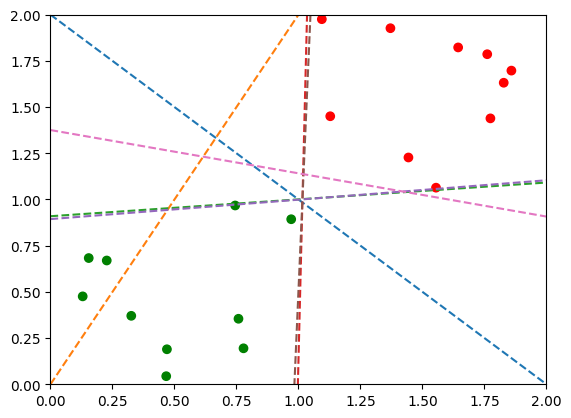

In [14]:
plt.xlim([0, 2])
plt.ylim([0, 2])
plt.scatter(X[:,1], X[:,2], c = colors)
abline(-1, 2)
abline(2, 0)

for run in range(5):

    clf = Perceptron(3)

    for epoch in range(10000):
        errors = 0

        for x, y in zip(X, Y):

            if clf.predict(x) != y:
                errors += 1

            clf.weights = gd_step(
                clf,
                x,
                y,
                0.01,
                loss_perceptron
            )

        if errors == 0:
            break

    # Calculate accuracy
    correct = 0

    for x, y in zip(X, Y):
        if clf.predict(x) == y:
            correct += 1

    accuracy = correct / len(Y)

    print(
        "Run", run + 1,
        "- Epochs:", epoch + 1,
        "- Accuracy:", accuracy
    )

    slope, intercept = weights_to_slope_intercept(clf.weights)
    abline(slope, intercept)

plt.show()

1. The decision boundaries can be somewhat different between the five runs. This happens because each Perceptron starts with randomly initialized weights.

2. Different weight vectors can still correctly classify the same data because there can be more than one line that separates the two groups without making any mistakes.

3. A good decision boundary is one that correctly separates the positive and negative examples and ideally leaves some space between the line and the points.

4. The training plot alone cannot tell us which boundary will perform best on new data. Several boundaries may classify all of the training examples correctly, but they could behave differently when given examples that were not part of the training set.


<h3>Task 5: Do Task 4 Again with a New Loss</h3>

<p>Repeat task 4, generating 5 plots of the separators corresponding to hyperplanes, but this time use the loss function below instead of perceptron loss above.</p>

**Observation:**<p>How are the results different? Why does the results look different?</p>


Run 1 - Epochs: 23 - Accuracy: 1.0
Run 2 - Epochs: 24 - Accuracy: 1.0
Run 3 - Epochs: 29 - Accuracy: 1.0
Run 4 - Epochs: 35 - Accuracy: 1.0
Run 5 - Epochs: 39 - Accuracy: 1.0


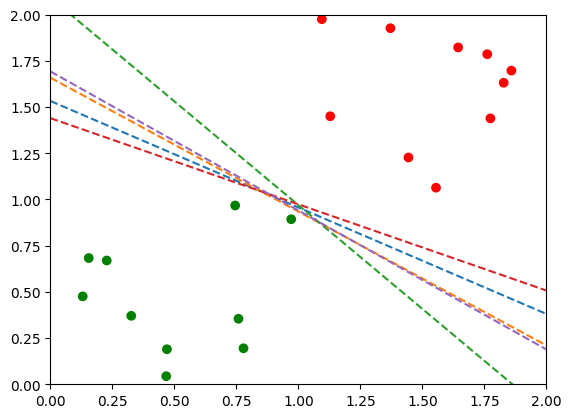

In [15]:
def loss_perceptron_margin(y, activation):
    return 0 if y * activation > 1 else -y * activation + 1

plt.xlim([0, 2])
plt.ylim([0, 2])
plt.scatter(X[:, 1], X[:, 2], c=colors)

for run in range(5):

    clf = Perceptron(3)

    for epoch in range(10000):
        errors = 0

        for x, y in zip(X, Y):

            if clf.predict(x) != y:
                errors += 1

            clf.weights = gd_step(
                clf,
                x,
                y,
                0.01,
                loss_perceptron_margin
            )

        if errors == 0:
            break

    # Calculate accuracy
    correct = 0

    for x, y in zip(X, Y):
        if clf.predict(x) == y:
            correct += 1

    accuracy = correct / len(Y)

    print(
        "Run", run + 1,
        "- Epochs:", epoch + 1,
        "- Accuracy:", accuracy
    )

    slope, intercept = weights_to_slope_intercept(clf.weights)
    abline(slope, intercept)

plt.show()

The results can look different because the new loss function does more than just check whether a point is classified correctly. It also encourages correctly classified points to be farther away from the decision boundary. Because of this margin, the learned lines may have more separation between the two classes and may be less sensitive to small changes in the training data.


<h3> Bonus Task 6: Multi-Class Perceptron</h3>

Implement a variation of the perceptron algorithm that works for a dataset with more than two classes. Did you need to modify the weight update rule. If yes, how did you do it?

<h6> Courtesy: This assignment has been updated and modified from an original assignment of Dr. Tim Oates</h6>

